# Initial Explainability Analysis for RUL Prediction

This notebook performs initial explainability analysis for the FD001 RUL prediction experiments. The focus is on explaining the best classical baseline and the initial multi-view deep learning model using feature importance, SHAP analysis, view-level contribution checks, and representative local prediction examples.

## 1. Imports and Setup

In [1]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

try:
    import shap
    SHAP_AVAILABLE = True
    print(f'SHAP version: {shap.__version__}')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not available. Install with: pip install shap')

import tensorflow as tf
from tensorflow.keras.models import load_model

print(f'TensorFlow: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

SHAP version: 0.52.0
TensorFlow: 2.20.0
GPU available: True


## 1b. Colab Path Setup

Run on Google Colab with T4 GPU. Ensure the following are already on Drive from earlier steps:
- `data/processed/val_c_fd001.csv`
- `data/processed/multiview/val_multiview_fd001_window30.npz`
- `data/processed/multiview/val_multiview_meta_fd001_window30.csv`
- `models/classical/XGBoost_C_fd001.joblib`
- `models/multiview/MultiViewGRUFusion_window30_fd001.keras`

In [2]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install -q shap
    import shap
    SHAP_AVAILABLE = True
    BASE = '/content/drive/MyDrive/Dissertation/Project/dissertation-rul-xai'
else:
    BASE = '..'

DATA_DIR          = f'{BASE}/data/processed'
METRICS_DIR       = f'{BASE}/reports/metrics'
FIG_DIR           = f'{BASE}/reports/figures'
PRED_DIR          = f'{BASE}/reports/predictions'
EXPLAIN_DIR       = f'{BASE}/reports/explainability'
MODEL_CLASSICAL   = f'{BASE}/models/classical'
MODEL_MULTIVIEW   = f'{BASE}/models/multiview'
ARRAY_DIR         = f'{BASE}/data/processed/multiview'

for d in [EXPLAIN_DIR, FIG_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Paths set up.')

Mounted at /content/drive
Paths set up.


## 2. Load Data and Models

In [3]:
val_c = pd.read_csv(f'{DATA_DIR}/val_c_fd001.csv')

metadata_cols  = ['unit_number', 'time_in_cycles', 'RUL', 'RUL_capped']
feature_c_cols = [c for c in val_c.columns if c not in metadata_cols]

X_val_c = val_c[feature_c_cols]
y_val_c = val_c['RUL_capped'].values

for col in metadata_cols:
    assert col not in feature_c_cols
assert 'cycle_index' in feature_c_cols
assert 'time_in_cycles' not in feature_c_cols

print(f'Feature Set C validation: {X_val_c.shape}')
print(f'Features: {len(feature_c_cols)}')

Feature Set C validation: (4291, 57)
Features: 57


In [4]:
xgb_model    = joblib.load(f'{MODEL_CLASSICAL}/XGBoost_C_fd001.joblib')
fusion_model = load_model(f'{MODEL_MULTIVIEW}/MultiViewGRUFusion_window30_fd001.keras')

print('XGBoost model loaded.')
print('MultiViewGRUFusion model loaded.')

XGBoost model loaded.
MultiViewGRUFusion model loaded.


In [5]:
WINDOW_SIZE = 30

val_mv      = np.load(f'{ARRAY_DIR}/val_multiview_fd001_window{WINDOW_SIZE}.npz')
X_val_seq   = val_mv['X_seq']
X_val_der   = val_mv['X_derived']
y_val_mv    = val_mv['y']
val_meta_mv = pd.read_csv(f'{ARRAY_DIR}/val_multiview_meta_fd001_window{WINDOW_SIZE}.csv')

print(f'X_val_seq:  {X_val_seq.shape}')
print(f'X_val_der:  {X_val_der.shape}')
print(f'y_val_mv:   {y_val_mv.shape}')

X_val_seq:  (3711, 30, 14)
X_val_der:  (3711, 43)
y_val_mv:   (3711,)


In [6]:
def evaluate_predictions(y_true, y_pred):
    y_pred = np.clip(y_pred.reshape(-1), 0, 125)
    rmse   = root_mean_squared_error(y_true, y_pred)
    mae    = mean_absolute_error(y_true, y_pred)
    r2     = r2_score(y_true, y_pred)
    return round(float(rmse), 4), round(float(mae), 4), round(float(r2), 4)

## 3. XGBoost Feature Importance

The feature importance values provide an initial global explanation of the XGBoost baseline. These values indicate which engineered or raw features were most used by the tree ensemble. They should be interpreted as model-specific importance scores, not as causal effects.

In [7]:
importance_df = pd.DataFrame({
    'feature':    feature_c_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df.to_csv(f'{EXPLAIN_DIR}/xgboost_feature_importance_fd001.csv', index=False)

print(importance_df.head(20).to_string(index=False))

                    feature  importance
 sensor_measurement_4_rmean    0.275829
sensor_measurement_11_rmean    0.213739
sensor_measurement_15_rmean    0.179100
 sensor_measurement_2_rmean    0.047461
sensor_measurement_17_rmean    0.042644
sensor_measurement_11_delta    0.026551
 sensor_measurement_9_delta    0.025197
 sensor_measurement_3_rmean    0.022704
sensor_measurement_21_rmean    0.019385
                cycle_index    0.017717
 sensor_measurement_8_delta    0.010920
sensor_measurement_13_delta    0.010060
sensor_measurement_15_delta    0.008948
 sensor_measurement_4_delta    0.008941
sensor_measurement_20_delta    0.008756
 sensor_measurement_9_rmean    0.008147
 sensor_measurement_7_delta    0.007001
sensor_measurement_12_rmean    0.006555
sensor_measurement_14_delta    0.006544
sensor_measurement_21_delta    0.005555


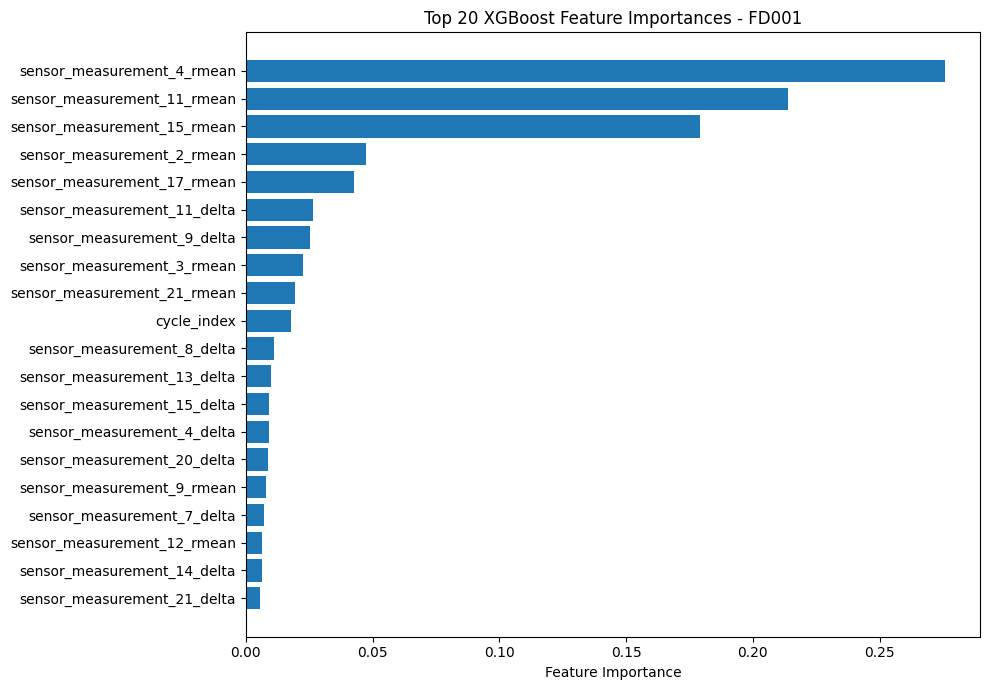

In [8]:
top_n  = 20
top_df = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_df['feature'], top_df['importance'])
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top {top_n} XGBoost Feature Importances - FD001')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/xgboost_feature_importance_top20_fd001.png', dpi=300)
plt.show()

## 4. SHAP Global Explainability for XGBoost

The SHAP summary plot is used to understand which features contribute most to the XGBoost RUL predictions across validation samples. The SHAP values indicate direction and relative contribution of features to the model output. This provides stronger explanation than model-native feature importance, although it remains a model-level explanation rather than a physical causal explanation.

In [9]:
SHAP_SAMPLE_SIZE = min(1000, len(X_val_c))
X_shap = X_val_c.sample(n=SHAP_SAMPLE_SIZE, random_state=42)

if SHAP_AVAILABLE:
    explainer   = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)
    print(f'SHAP values computed for {SHAP_SAMPLE_SIZE} samples.')
    print(f'SHAP values shape: {np.array(shap_values).shape}')
else:
    print('SHAP not available. Skipping SHAP analysis.')

SHAP values computed for 1000 samples.
SHAP values shape: (1000, 57)


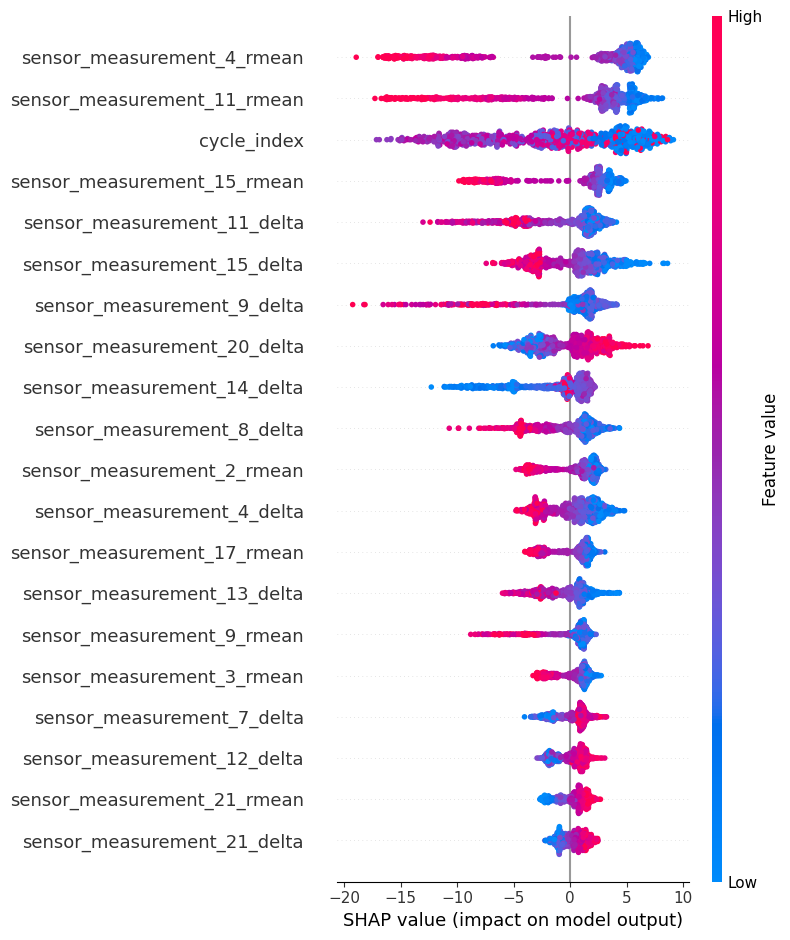

In [10]:
if SHAP_AVAILABLE:
    shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/shap_summary_xgboost_fd001.png', dpi=300, bbox_inches='tight')
    plt.show()

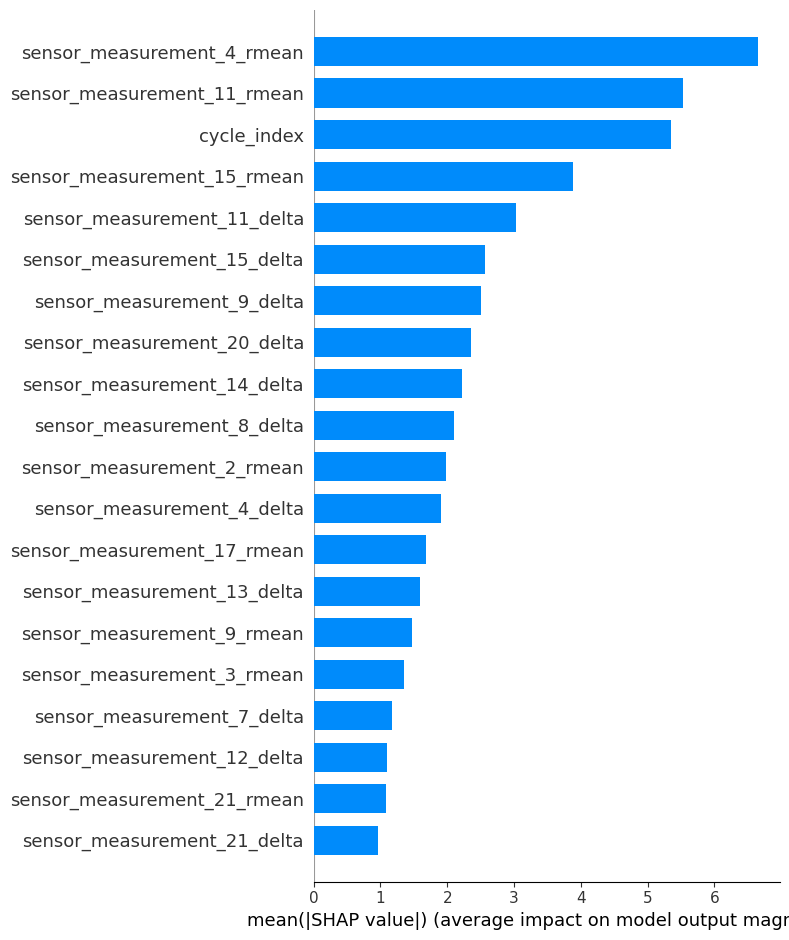

In [11]:
if SHAP_AVAILABLE:
    shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=20)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/shap_bar_xgboost_fd001.png', dpi=300, bbox_inches='tight')
    plt.show()

## 5. SHAP Feature Ranking and Dependence Plots

SHAP dependence plots are used to inspect how important feature values relate to their contribution to predicted RUL. These plots help identify whether increasing or decreasing degradation-related features tends to push the prediction higher or lower.

In [12]:
if SHAP_AVAILABLE:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_rank_df = pd.DataFrame({
        'feature':       X_shap.columns,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    shap_rank_df.to_csv(f'{EXPLAIN_DIR}/xgboost_shap_feature_ranking_fd001.csv', index=False)

    top_shap_features = shap_rank_df['feature'].head(3).tolist()
    print('Top 3 SHAP features:', top_shap_features)
    print()
    print(shap_rank_df.head(10).to_string(index=False))

Top 3 SHAP features: ['sensor_measurement_4_rmean', 'sensor_measurement_11_rmean', 'cycle_index']

                    feature  mean_abs_shap
 sensor_measurement_4_rmean       6.651353
sensor_measurement_11_rmean       5.529418
                cycle_index       5.352144
sensor_measurement_15_rmean       3.879201
sensor_measurement_11_delta       3.026035
sensor_measurement_15_delta       2.558428
 sensor_measurement_9_delta       2.502992
sensor_measurement_20_delta       2.359407
sensor_measurement_14_delta       2.217364
 sensor_measurement_8_delta       2.099544


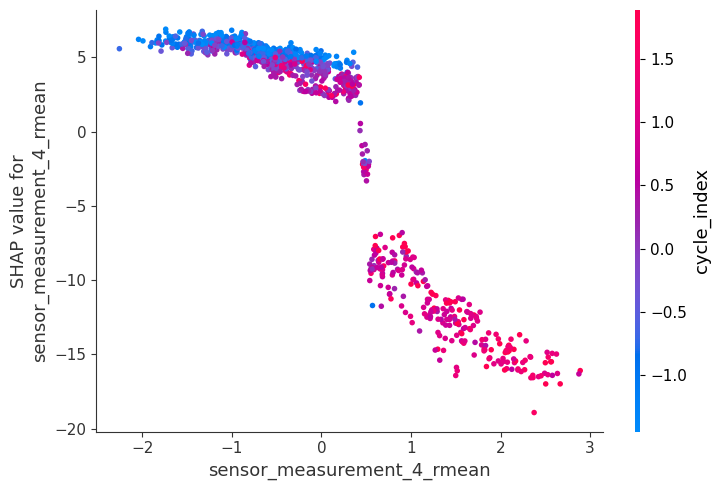

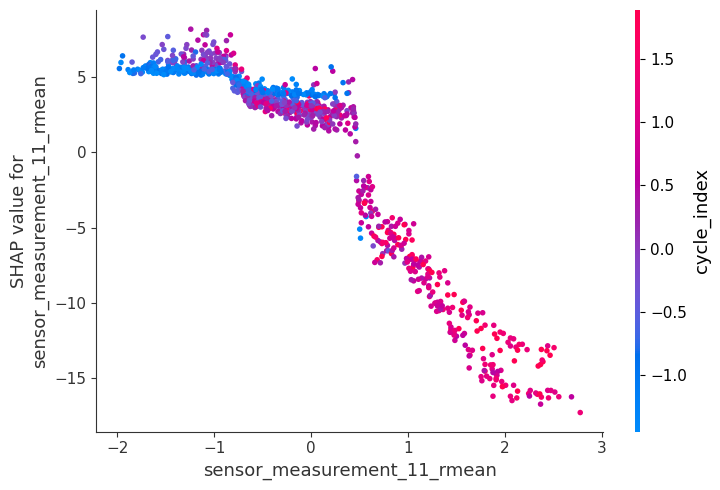

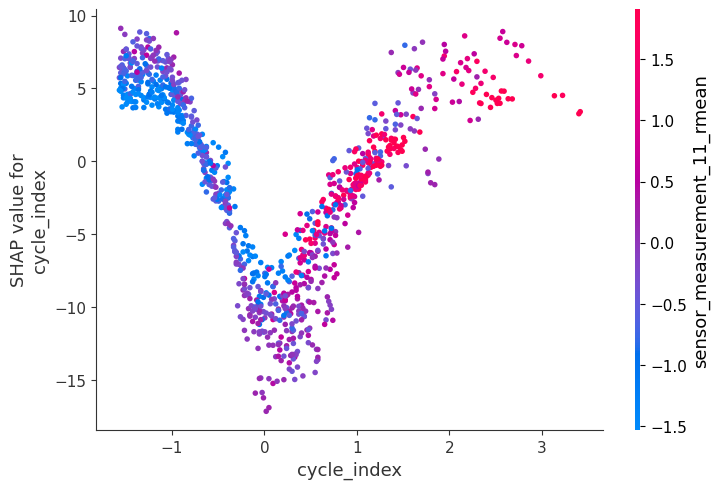

In [13]:
if SHAP_AVAILABLE:
    for feature in top_shap_features:
        shap.dependence_plot(feature, shap_values, X_shap, show=False)
        plt.tight_layout()
        safe_name = feature.replace('/', '_')
        plt.savefig(
            f'{FIG_DIR}/shap_dependence_{safe_name}_fd001.png',
            dpi=300, bbox_inches='tight'
        )
        plt.show()

## 6. View-Level Explainability for MultiViewGRUFusion

The view masking analysis is used as an initial view-level explainability check. It measures how the fusion model performance changes when one input view is removed at inference time by replacing it with zeros. A larger increase in error indicates stronger dependence on that view.

Because the model inputs are standardised, replacing a view with zeros approximates a mean-value masking strategy. This allows a simple first check of view dependence without introducing extreme out-of-distribution values.

This is not a full causal explanation, but it provides evidence about the relative contribution of the sensor sequence and derived degradation views.

In [14]:
pred_normal     = fusion_model.predict([X_val_seq, X_val_der], verbose=0).reshape(-1)
normal_rmse, normal_mae, normal_r2 = evaluate_predictions(y_val_mv, pred_normal)
print(f'Both views:  RMSE {normal_rmse}  MAE {normal_mae}  R2 {normal_r2}')

Both views:  RMSE 12.0657  MAE 8.9406  R2 0.9168


In [15]:
pred_no_seq = fusion_model.predict(
    [np.zeros_like(X_val_seq), X_val_der], verbose=0
).reshape(-1)
no_seq_rmse, no_seq_mae, no_seq_r2 = evaluate_predictions(y_val_mv, pred_no_seq)
print(f'Sensor seq masked (derived only):  RMSE {no_seq_rmse}  MAE {no_seq_mae}  R2 {no_seq_r2}')

Sensor seq masked (derived only):  RMSE 15.5505  MAE 12.6154  R2 0.8618


In [16]:
pred_no_der = fusion_model.predict(
    [X_val_seq, np.zeros_like(X_val_der)], verbose=0
).reshape(-1)
no_der_rmse, no_der_mae, no_der_r2 = evaluate_predictions(y_val_mv, pred_no_der)
print(f'Derived view masked (seq only):    RMSE {no_der_rmse}  MAE {no_der_mae}  R2 {no_der_r2}')

Derived view masked (seq only):    RMSE 42.5692  MAE 36.1661  R2 -0.0354


In [17]:
view_impact_df = pd.DataFrame([
    {
        'condition':   'both_views_available',
        'description': 'Sensor sequence view + derived degradation view',
        'rmse': normal_rmse, 'mae': normal_mae, 'r2': normal_r2
    },
    {
        'condition':   'sensor_sequence_masked',
        'description': 'Derived degradation view only at inference',
        'rmse': no_seq_rmse, 'mae': no_seq_mae, 'r2': no_seq_r2
    },
    {
        'condition':   'derived_view_masked',
        'description': 'Sensor sequence view only at inference',
        'rmse': no_der_rmse, 'mae': no_der_mae, 'r2': no_der_r2
    }
])

view_impact_df.to_csv(
    f'{EXPLAIN_DIR}/multiview_view_masking_explainability_fd001.csv', index=False
)
print(view_impact_df.to_string(index=False))

             condition                                     description    rmse     mae      r2
  both_views_available Sensor sequence view + derived degradation view 12.0657  8.9406  0.9168
sensor_sequence_masked      Derived degradation view only at inference 15.5505 12.6154  0.8618
   derived_view_masked          Sensor sequence view only at inference 42.5692 36.1661 -0.0354


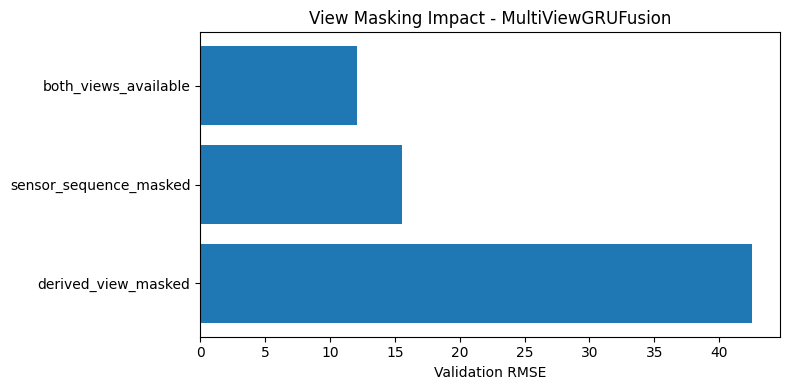

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(view_impact_df['condition'], view_impact_df['rmse'])
ax.set_xlabel('Validation RMSE')
ax.set_title('View Masking Impact - MultiViewGRUFusion')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/multiview_view_masking_rmse_fd001.png', dpi=300)
plt.show()

## 7. Local Prediction Case Analysis

The local case analysis compares normal and view-masked predictions for representative samples: one with a good prediction, one with the largest under-prediction, and one with the largest over-prediction. This helps inspect whether a specific prediction depends more on the sensor sequence view or the derived degradation feature view.

In [19]:
fusion_pred_df              = val_meta_mv.copy()
fusion_pred_df['prediction'] = np.clip(pred_normal, 0, 125)
fusion_pred_df['error']      = fusion_pred_df['prediction'] - fusion_pred_df['RUL_capped']
fusion_pred_df['abs_error']  = fusion_pred_df['error'].abs()

case_positions = {
    'good_prediction':          fusion_pred_df['abs_error'].idxmin(),
    'largest_under_prediction': fusion_pred_df['error'].idxmin(),
    'largest_over_prediction':  fusion_pred_df['error'].idxmax(),
}

case_impact_records = []

for case_type, idx in case_positions.items():
    seq_sample = X_val_seq[idx:idx + 1]
    der_sample = X_val_der[idx:idx + 1]

    pred_both       = np.clip(fusion_model.predict([seq_sample, der_sample],                       verbose=0).reshape(-1)[0], 0, 125)
    pred_seq_masked = np.clip(fusion_model.predict([np.zeros_like(seq_sample), der_sample],        verbose=0).reshape(-1)[0], 0, 125)
    pred_der_masked = np.clip(fusion_model.predict([seq_sample, np.zeros_like(der_sample)],        verbose=0).reshape(-1)[0], 0, 125)

    row = fusion_pred_df.iloc[idx]

    case_impact_records.append({
        'case_type':                  case_type,
        'unit_number':                row['unit_number'],
        'time_in_cycles':             row['time_in_cycles'],
        'actual_rul_capped':          row['RUL_capped'],
        'prediction_both_views':      pred_both,
        'prediction_sensor_masked':   pred_seq_masked,
        'prediction_derived_masked':  pred_der_masked,
        'error_both_views':           pred_both - row['RUL_capped'],
    })

case_impact_df = pd.DataFrame(case_impact_records)
print(case_impact_df.to_string(index=False))


               case_type  unit_number  time_in_cycles  actual_rul_capped  prediction_both_views  prediction_sensor_masked  prediction_derived_masked  error_both_views
         good_prediction          2.0            30.0              125.0             125.000000                125.000000                  60.402390          0.000000
largest_under_prediction         22.0            61.0              125.0              74.792839                 75.851738                  61.746284        -50.207161
 largest_over_prediction         93.0           112.0               43.0              95.819969                 97.998062                  59.879635         52.819969


In [20]:
# Mid-range good prediction: actual RUL_capped in [40, 90], lowest abs_error
midrange_mask = (fusion_pred_df['RUL_capped'] >= 40) & (fusion_pred_df['RUL_capped'] <= 90)
midrange_case_idx = fusion_pred_df[midrange_mask]['abs_error'].idxmin()

seq_sample = X_val_seq[midrange_case_idx:midrange_case_idx + 1]
der_sample = X_val_der[midrange_case_idx:midrange_case_idx + 1]

pred_both_mr       = np.clip(fusion_model.predict([seq_sample, der_sample],                       verbose=0).reshape(-1)[0], 0, 125)
pred_seq_masked_mr = np.clip(fusion_model.predict([np.zeros_like(seq_sample), der_sample],        verbose=0).reshape(-1)[0], 0, 125)
pred_der_masked_mr = np.clip(fusion_model.predict([seq_sample, np.zeros_like(der_sample)],        verbose=0).reshape(-1)[0], 0, 125)

row_mr = fusion_pred_df.iloc[midrange_case_idx]

midrange_record = {
    'case_type':                  'good_midrange_prediction',
    'unit_number':                row_mr['unit_number'],
    'time_in_cycles':             row_mr['time_in_cycles'],
    'actual_rul_capped':          row_mr['RUL_capped'],
    'prediction_both_views':      pred_both_mr,
    'prediction_sensor_masked':   pred_seq_masked_mr,
    'prediction_derived_masked':  pred_der_masked_mr,
    'error_both_views':           pred_both_mr - row_mr['RUL_capped'],
}

case_impact_df_updated = pd.concat(
    [case_impact_df, pd.DataFrame([midrange_record])], ignore_index=True
)
case_impact_df_updated.to_csv(
    f'{EXPLAIN_DIR}/local_view_masking_cases_multiview_fd001.csv', index=False
)
print(case_impact_df_updated.to_string(index=False))


               case_type  unit_number  time_in_cycles  actual_rul_capped  prediction_both_views  prediction_sensor_masked  prediction_derived_masked  error_both_views
         good_prediction          2.0            30.0              125.0             125.000000                125.000000                  60.402390          0.000000
largest_under_prediction         22.0            61.0              125.0              74.792839                 75.851738                  61.746284        -50.207161
 largest_over_prediction         93.0           112.0               43.0              95.819969                 97.998062                  59.879635         52.819969
good_midrange_prediction         53.0           154.0               41.0              41.007362                 49.869820                  53.176117          0.007362


In [21]:
local_prediction_cases = case_impact_df_updated[[
    'case_type', 'unit_number', 'time_in_cycles',
    'actual_rul_capped', 'prediction_both_views', 'error_both_views'
]].copy()

local_prediction_cases = local_prediction_cases.rename(columns={
    'actual_rul_capped':   'RUL_capped',
    'prediction_both_views': 'prediction',
    'error_both_views':    'error'
})
local_prediction_cases['abs_error'] = local_prediction_cases['error'].abs()

local_prediction_cases.to_csv(
    f'{EXPLAIN_DIR}/local_prediction_cases_multiview_fd001.csv', index=False
)
print(local_prediction_cases.to_string(index=False))


               case_type  unit_number  time_in_cycles  RUL_capped  prediction      error  abs_error
         good_prediction          2.0            30.0       125.0  125.000000   0.000000   0.000000
largest_under_prediction         22.0            61.0       125.0   74.792839 -50.207161  50.207161
 largest_over_prediction         93.0           112.0        43.0   95.819969  52.819969  52.819969
good_midrange_prediction         53.0           154.0        41.0   41.007362   0.007362   0.007362


## 8. Neural-Network Explainability: Planned Future Work

Neural-network-specific SHAP or gradient-based explanation for the fusion model is planned as future work. For the current stage, view-level masking and SHAP analysis on the XGBoost baseline are used as initial explainability evidence.

## 9. Observations

1. XGBoost feature importance and SHAP analysis provide global feature-level explanations for the strongest classical baseline.
2. Derived degradation features such as rolling statistics and delta features can be inspected for their contribution to RUL prediction.
3. View masking provides an initial explanation of how much the multi-view fusion model depends on each input view.
4. The local case analysis helps understand examples of accurate prediction, under-prediction, and over-prediction.
5. These explainability results are model-level explanations and should not be interpreted as physical causal explanations.
6. The results will be used to support the explainability section of the mid-semester report and to guide later robustness analysis.

## 10. Generated Artefacts

In [22]:
print('Explainability CSVs:')
for f in sorted(os.listdir(EXPLAIN_DIR)):
    print(f'  {f}')

print('\nFigures:')
for f in sorted(os.listdir(FIG_DIR)):
    if any(k in f for k in ['shap', 'xgboost_feature', 'view_masking']):
        print(f'  {f}')

Explainability CSVs:
  local_prediction_cases_multiview_fd001.csv
  local_view_masking_cases_multiview_fd001.csv
  multiview_view_masking_explainability_fd001.csv
  xgboost_feature_importance_fd001.csv
  xgboost_shap_feature_ranking_fd001.csv

Figures:
  multiview_view_masking_rmse_fd001.png
  shap_bar_xgboost_fd001.png
  shap_dependence_cycle_index_fd001.png
  shap_dependence_sensor_measurement_11_rmean_fd001.png
  shap_dependence_sensor_measurement_4_rmean_fd001.png
  shap_summary_xgboost_fd001.png
  xgboost_feature_importance_top20_fd001.png
